In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np
import re
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy
import xarray as xr
from scipy.stats import gaussian_kde

In [2]:
import pandas as pd
import numpy as np
import re

def read_tracks(filename=None, var_names=None):
    regex_clean = re.compile(r'&')
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    assert len(lines) > 0, "File does not exist or is empty"

    i_start = [i for i, line in enumerate(lines) if line.startswith('TRACK_ID')]
    n_tracks = len(i_start)

    tracks = []
    for ii in range(n_tracks):
        start_ = i_start[ii] + 2
        n_points = int(lines[i_start[ii] + 1].split()[1])
        track_lines = lines[start_:start_ + n_points]

        track_lines = [regex_clean.sub('', line).split() for line in track_lines]
        data = np.array(track_lines, dtype=float)
        data[data == 1e25] = np.nan

        columns = ['ID', 'start_time', 'median_time', 'name']
        split_line = lines[i_start[ii]].split()
        
        # Safely extract data with default values if indices are out of range
        id_id = split_line[1] if len(split_line) > 1 else 'unknown'
        start_time = split_line[3] if len(split_line) > 3 else 'unknown'
        median_time = split_line[5] if len(split_line) > 5 else 'unknown'
        name_storm = split_line[9] if len(split_line) > 9 else 'unknown'
        
        df = pd.DataFrame(data, columns=var_names[:data.shape[1]])
        df['ID'] = id_id
        df['start_time'] = start_time
        df['median_time'] = median_time
        df['name'] = name_storm
        
        tracks.append(df)

    result = pd.concat(tracks, ignore_index=True)
    result['ID'] = result['ID'].astype('category')

    return result

In [2]:
def read_tracks(filename=None, var_names=None):
    with open(filename, 'r') as file:
        lines = file.readlines()

    assert len(lines) > 0, "File does not exist or is empty"

    i_start = [i for i, line in enumerate(lines) if line.startswith('TRACK_ID')]
    n_tracks = len(i_start)
    #print(i_start, n_tracks)
    tracks = []
    for ii in range(n_tracks):
        start_ = i_start[ii] + 2
        n_points = int(lines[i_start[ii] + 1].split()[1])
        track_lines = lines[start_:start_ + n_points]
        track_lines = [re.sub(r'&', '', line).split() for line in track_lines]
        data = np.array(track_lines, dtype=float)
        data[data == 1e25] = np.nan

        df = pd.DataFrame(data)
        id_id = '_'.join(lines[i_start[ii]].split()[1:2])
        start_time = '_'.join(lines[i_start[ii]].split()[3:4])
        median_time = '_'.join(lines[i_start[ii]].split()[5:6])
        name_storm = '_'.join(lines[i_start[ii]].split()[9:10])
        
        df['ID'] = id_id
        df['start_time'] = start_time
        df['median_time'] = median_time
        df['name'] = name_storm
        
        tracks.append(df)

    result = pd.concat(tracks, ignore_index=True)

    result['ID'] = result['ID'].astype('category')

    if var_names:
        for idx, name in enumerate(var_names, start=0):
            result.rename(columns={idx: name}, inplace=True)

    return result

def add_wrap_id(df):
    df.columns = [str(col) for col in df.columns]
    lon_cols = [col for col in df.columns if col.startswith('lon_')]

    for lon_col in lon_cols:
        suffix = lon_col.split('_')[-1]
        lat_col = f'lat_{suffix}'

        def calculate_wrap_id(lon):
            diffs = np.diff(np.concatenate(([lon.iloc[0]], lon))) 
            wraps = diffs > 180 
            return np.cumsum(wraps) + 1  

        if 'ID' in df.columns:
            df[f'wrap_{suffix}'] = df.groupby('ID')[lon_col].transform(calculate_wrap_id)
            df[f'ID2_{suffix}'] = df['ID'].astype(str) + '.' + df[f'wrap_{suffix}'].astype(str)
        else:
            df[f'wrap_{suffix}'] = calculate_wrap_id(df[lon_col])
            df[f'ID2_{suffix}'] = df.index.astype(str) + '.' + df[f'wrap_{suffix}'].astype(str)

        df.drop(f'wrap_{suffix}', axis=1, inplace=True)
    
    df['TRACK_ID'] = df['ID'].str.split('_').str[-1]

    return df

In [ ]:
def plot_track(data, var, fig_title):
    '''
    data: storm track dataframe
    var: 'vor', 'wind', 'mslp'
    '''

    var_name = {'vor': (0,9, 'vorticity (x10-5 s-1)'), 
                'wind': (10,50, '925-hPa windspeed max (ms-1)'), 
                'mslp': (960,1010, 'mean sea level pressure (hPa)')}
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.NorthPolarStereo(central_longitude=0)
    data[f'lon_{var}'] = ((data[f'lon_{var}'] + 180) % 360) - 180

    
    fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    cmap = plt.cm.viridis_r
    norm = plt.Normalize(var_name[var][0],var_name[var][1])
    data['color'] = cmap(norm(data[f'var_{var}']))
    
    for name, group in data.groupby('ID'):
        points = group[[f'lon_{var}', f'lat_{var}']].values
        ax.scatter(group[f'lon_{var}'], group[f'lat_{var}'], color=cmap(norm(group[f'var_{var}'])), 
                   s=1, transform=datacrs)
        for i in range(len(points)-1):
            line = np.array([points[i], points[i+1]])
            ax.plot(line[:, 0], line[:, 1], 
                    color=cmap(norm((group[f'var_{var}'].iloc[i] + group[f'var_{var}'].iloc[i+1])/2)),
                    linewidth=0.5, transform=datacrs)  
        
    ax.set_title(fig_title)
    labelin = f'{var_name[var][2]}'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                 orientation='horizontal', label=labelin)
    #plt.savefig('storm_19792021_wind.png', dpi=300)
    plt.show()

In [8]:
def plot_track(data, var, fig_title):
    '''
    data: storm track dataframe
    var: 'vor', 'wind', 'mslp'
    '''

    var_name = {'vor': (0,9, 'vorticity (x10-5 s-1)'), 
                'wind': (10,50, '925-hPa windspeed max (ms-1)'), 
                'mslp': (960,1010, 'mean sea level pressure (hPa)')}
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.NorthPolarStereo(central_longitude=0)
    data[f'lon_{var}'] = ((data[f'lon_{var}'] + 180) % 360) - 180
    
    fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cfeature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    cmap = plt.cm.viridis_r
    norm = plt.Normalize(var_name[var][0], var_name[var][1])
    colors = cmap(norm(data[f'var_{var}']))
    
    for name, group in data.groupby('ID'):
        lon = group[f'lon_{var}'].values
        lat = group[f'lat_{var}'].values
        color = colors[group.index]
        
        # Plot all points in one call
        ax.scatter(lon, lat, color=color, s=1, transform=datacrs)
        
        # Efficiently create lines between consecutive points
        for i in range(len(lon) - 1):
            ax.plot([lon[i], lon[i+1]], [lat[i], lat[i+1]], 
                    color=cmap(norm((group[f'var_{var}'].iloc[i] + group[f'var_{var}'].iloc[i+1]) / 2)),
                    linewidth=0.5, transform=datacrs)
        
    ax.set_title(fig_title)
    labelin = f'{var_name[var][2]}'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                 orientation='horizontal', label=labelin)
    plt.show()


In [13]:
def plot_density (data, var, fig_title):
    lons = data[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
    lats = data[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.NorthPolarStereo(central_longitude=0)
    
    fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})
    #ax.set_extent([-95, 65, 25, 90], crs=ccrs.PlateCarree())
    #ax.set_extent([-180, 28, 25, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    lon = np.linspace(-180, 180, 100)
    lat = np.linspace(-90, 90, 100)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])
    
    xy = np.vstack([lons, lats])
    kde = gaussian_kde(xy)
    z = kde(grid_coords).reshape(lon_grid.shape)
    
    sc = ax.scatter(lons, lats, c=kde(xy), s=10, cmap='viridis_r', edgecolor='none', transform=datacrs)
    cs = ax.contour(lon_grid, lat_grid, z, levels=6, colors='k', linewidths=0.5, transform=datacrs)
    plt.clabel(cs, inline=1, fontsize=5, fmt='%.4f')
    
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
    cbar.set_label('Density')
    ax.set_title(fig_title)
    #plt.savefig('storm_19792021_density.png', dpi=300)
    plt.show()

In [3]:
def to_datetime(df):
    df['date'] = df['date'].astype(str)
    df['start_time'] = df['start_time'].astype(str)
    df['median_time'] = df['median_time'].astype(str)
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d%H.%f')
    df['start_time'] = pd.to_datetime(df['start_time'], format='%Y%m%d%H')
    df['median_time'] = pd.to_datetime(df['median_time'], format='%Y%m%d%H', errors='coerce')
    
    return df

def get_season(date):
    year = date.year
    if date.month in [10, 11, 12]:
        return f"{year}-{year+1}"
    elif date.month in [1, 2, 3]:
        return f"{year-1}-{year}"
    else:
        return None 

In [4]:
fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks/'
filename = fpath + 'ERA5_VOR850_1hr_oct-mar20212022_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'

with open(filename, 'r') as file:
    for i in range(8):
        print(file.readline().strip())

0
0 0
TRACK_NUM      3490 ADD_FLD    3   9 &111
TRACK_ID  1 START_TIME 2021100100
POINT_NUM  46
2021100100 316.288605 6.533656 2.588414e+00 & 3.128009e+02 & 5.472016e+00 & 1.011661e+03 & 3.116250e+02 & 9.133487e+00 & 1.131191e+01 & 3.130312e+02 & 1.138173e+01 & 9.158251e+00 &
2021100101 316.053741 6.525511 2.615831e+00 & 3.148244e+02 & 4.635773e+00 & 1.012083e+03 & 3.113438e+02 & 9.133487e+00 & 1.109850e+01 & 3.130312e+02 & 1.081967e+01 & 9.497718e+00 &
2021100102 315.755066 6.478238 2.567494e+00 & 3.172072e+02 & 5.706082e+00 & 1.012187e+03 & 3.135938e+02 & 9.133487e+00 & 1.186456e+01 & 3.121875e+02 & 1.110070e+01 & 9.899447e+00 &


In [10]:
path = '/gws/nopw/j04/canari/users/bjharvey/tracks/'
output_file =  'ERA5_VOR850_1hr_oct-mar20212022_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.txt' 

with open(output_file, 'w') as outfile:
    filename = path + 'ERA5_VOR850_1hr_oct-mar20212022_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'
    with open(filename, 'r') as infile:
        outfile.write(infile.read())

In [5]:
fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks/'
filename = fpath + 'ERA5_VOR850_1hr_oct-mar20212022_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'

var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

# Read the track data
trx_t = read_tracks(filename, var_names)
trx_t = to_datetime(trx_t)
trx_t['season'] = trx_t['start_time'].apply(get_season)
trx_t

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
0,2021-10-01 00:00:00,316.288605,6.533656,2.588414,312.8009,5.472016,1011.6610,311.6250,9.133487,11.31191,313.0312,11.38173,9.158251,1,2021-10-01 00:00:00,NaT,unknown,2021-2022
1,2021-10-01 01:00:00,316.053741,6.525511,2.615831,314.8244,4.635773,1012.0830,311.3438,9.133487,11.09850,313.0312,10.81967,9.497718,1,2021-10-01 00:00:00,NaT,unknown,2021-2022
2,2021-10-01 02:00:00,315.755066,6.478238,2.567494,317.2072,5.706082,1012.1870,313.5938,9.133487,11.86456,312.1875,11.10070,9.899447,1,2021-10-01 00:00:00,NaT,unknown,2021-2022
3,2021-10-01 03:00:00,315.368164,6.450430,2.584446,317.2607,6.334778,1011.6100,313.8750,8.852456,12.11530,312.4688,10.81967,10.149240,1,2021-10-01 00:00:00,NaT,unknown,2021-2022
4,2021-10-01 04:00:00,315.130249,6.447303,2.569178,315.9538,6.474955,1010.8690,313.0312,9.133487,12.45928,311.6250,11.10070,10.435960,1,2021-10-01 00:00:00,NaT,unknown,2021-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212833,2022-03-31 19:00:00,253.281281,52.871670,7.739974,253.5049,52.591620,997.0352,259.5938,53.536280,15.83161,251.1562,50.72598,11.710490,32623,2022-03-30 21:00:00,NaT,unknown,2021-2022
212834,2022-03-31 20:00:00,253.482239,52.941093,7.732875,253.7769,52.773410,997.3657,259.5938,53.536280,16.72056,251.4375,51.28803,11.483670,32623,2022-03-30 21:00:00,NaT,unknown,2021-2022
212835,2022-03-31 21:00:00,253.707535,53.047001,7.692232,254.0683,52.855430,997.1564,259.5938,53.536280,17.28619,251.7188,51.85009,11.251570,32623,2022-03-30 21:00:00,NaT,unknown,2021-2022
212836,2022-03-31 22:00:00,253.935608,53.155842,8.065690,254.2411,52.989730,996.6360,259.5938,53.536280,17.38802,253.1250,50.44494,12.570740,32623,2022-03-30 21:00:00,NaT,unknown,2021-2022


In [15]:
inside_bounds = trx_t[(trx_t['lon_vor'] >= -15) & (trx_t['lon_vor'] <= 25) & 
                      (trx_t['lat_vor'] >= 35) & (trx_t['lat_vor'] <= 70)]

valid_ids = inside_bounds['ID'].unique()
filtered_trx_t = trx_t[trx_t['ID'].isin(valid_ids)]
filtered_trx_t

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
504,2021-10-01 00:00:00,14.280143,59.590576,5.254971,NaN,NaN,1012.452,7.31250,55.22246,26.05398,7.87500,54.94143,15.756140,16,2021-10-01 00:00:00,NaT,unknown,2021-2022
505,2021-10-01 01:00:00,14.180651,59.835899,5.022840,NaN,NaN,1012.390,7.87500,55.22246,26.27874,7.87500,55.22246,15.857740,16,2021-10-01 00:00:00,NaT,unknown,2021-2022
506,2021-10-01 02:00:00,13.687209,59.897850,4.643922,NaN,NaN,1011.677,8.15625,55.50349,26.53469,7.87500,55.22246,16.054820,16,2021-10-01 00:00:00,NaT,unknown,2021-2022
507,2021-10-01 03:00:00,12.135706,59.396149,4.352773,NaN,NaN,1010.941,8.71875,55.78452,25.62876,7.03125,54.66040,16.199570,16,2021-10-01 00:00:00,NaT,unknown,2021-2022
508,2021-10-01 04:00:00,10.385736,59.046173,4.664992,NaN,NaN,1008.132,10.40625,56.90864,26.29054,7.87500,55.22246,16.422550,16,2021-10-01 00:00:00,NaT,unknown,2021-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212349,2022-03-31 19:00:00,42.283325,53.735771,5.041755,NaN,NaN,1009.261,43.03125,51.56907,23.33262,43.87500,51.85009,7.968852,32507,2022-03-30 08:00:00,NaT,unknown,2021-2022
212350,2022-03-31 20:00:00,43.713032,53.958275,5.187565,NaN,NaN,1009.198,43.87500,51.85009,23.21731,43.87500,51.85009,8.089783,32507,2022-03-30 08:00:00,NaT,unknown,2021-2022
212351,2022-03-31 21:00:00,45.282261,54.175426,5.404671,NaN,NaN,1009.828,45.84375,51.56907,23.13114,43.87500,52.13113,7.979499,32507,2022-03-30 08:00:00,NaT,unknown,2021-2022
212352,2022-03-31 22:00:00,46.392578,54.262409,5.648233,NaN,NaN,1009.955,46.12500,51.56907,24.50961,44.15625,51.85009,8.075846,32507,2022-03-30 08:00:00,NaT,unknown,2021-2022


In [19]:
cleaned_data = filtered_trx_t.dropna(subset=['lon_mslp'])
cleaned_data

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
512,2021-10-01 08:00:00,11.684464,60.775322,4.578266,8.989587,58.82393,1004.0800,12.93750,58.59482,26.78510,10.96875,58.03276,15.893840,16,2021-10-01 00:00:00,NaT,unknown,2021-2022
2719,2021-10-01 14:00:00,328.691162,47.323318,3.016048,329.457000,46.75023,1014.4940,330.18750,44.82434,23.07317,329.34380,45.94846,12.698160,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2720,2021-10-01 15:00:00,329.843506,47.154934,3.253570,330.296700,46.83046,1013.5070,331.31250,45.10537,23.87256,329.90620,45.94846,12.844040,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2721,2021-10-01 16:00:00,330.884186,47.125778,3.567819,331.198100,46.80598,1012.2370,331.87500,45.38640,24.21362,330.75000,45.94846,13.168670,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
2722,2021-10-01 17:00:00,331.821289,47.093708,3.738206,331.978600,46.77438,1011.0870,332.43750,45.38640,24.59600,331.59380,45.94846,13.588310,187,2021-10-01 14:00:00,NaT,unknown,2021-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212334,2022-03-31 04:00:00,23.747551,51.132339,3.220815,22.515960,49.88642,998.6885,31.21875,47.63464,15.61740,15.75000,54.66040,7.490456,32507,2022-03-30 08:00:00,NaT,unknown,2021-2022
212335,2022-03-31 05:00:00,25.641499,51.416256,3.357390,22.979760,49.80322,999.0342,32.34375,48.19670,17.08488,18.84375,54.94143,6.036747,32507,2022-03-30 08:00:00,NaT,unknown,2021-2022
212337,2022-03-31 07:00:00,28.004652,51.590763,3.347028,23.720070,49.18681,1000.0160,34.59375,48.19670,18.87228,31.50000,46.22949,10.538760,32507,2022-03-30 08:00:00,NaT,unknown,2021-2022
212339,2022-03-31 09:00:00,30.877214,51.584465,3.825811,26.153100,50.07535,1000.4790,34.03125,46.22949,19.59722,31.21875,45.66743,10.218200,32507,2022-03-30 08:00:00,NaT,unknown,2021-2022


In [18]:
filtered_trx_t['ID'].nunique()

269

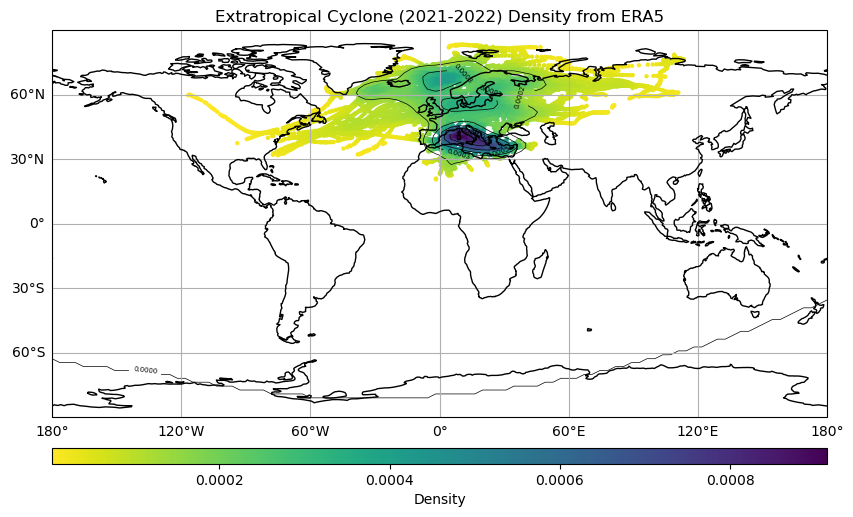

In [20]:
plot_density(cleaned_data, 'vor', 'Extratropical Cyclone (2021-2022) Density from ERA5')

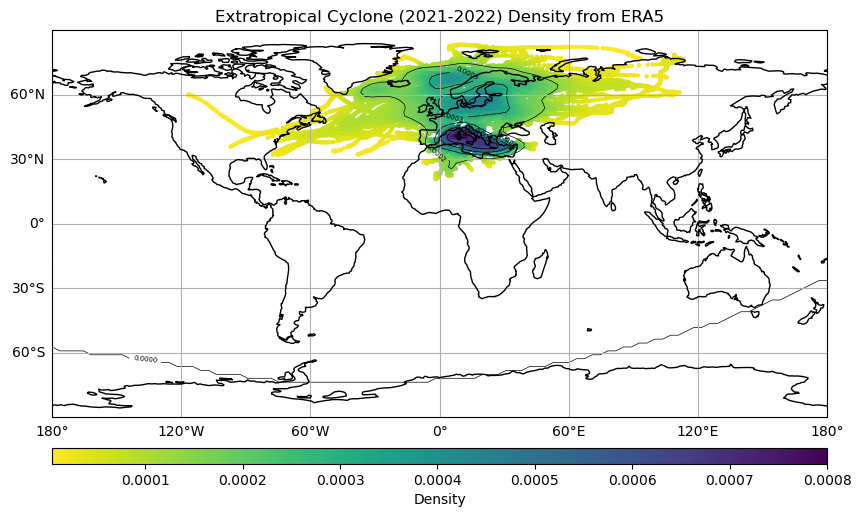

In [16]:
plot_density(filtered_trx_t, 'vor', 'Extratropical Cyclone (2021-2022) Density from ERA5')

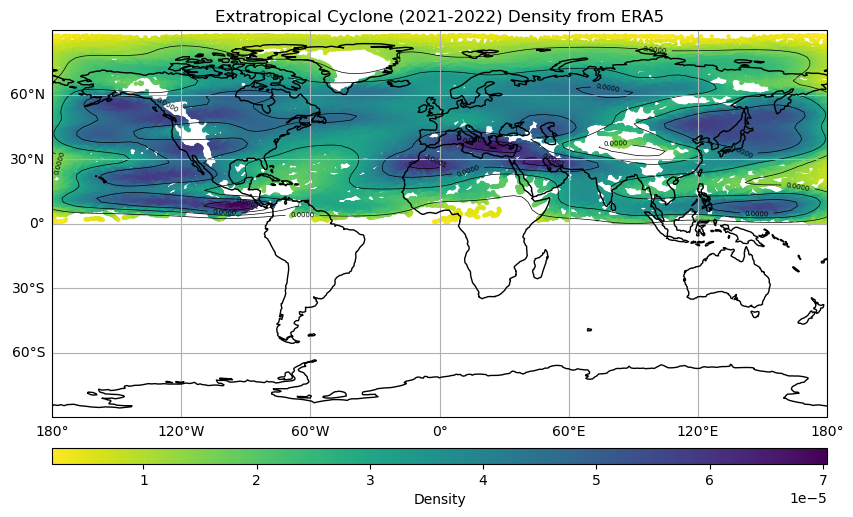

In [14]:
plot_density(trx_t, 'vor', 'Extratropical Cyclone (2021-2022) Density from ERA5')

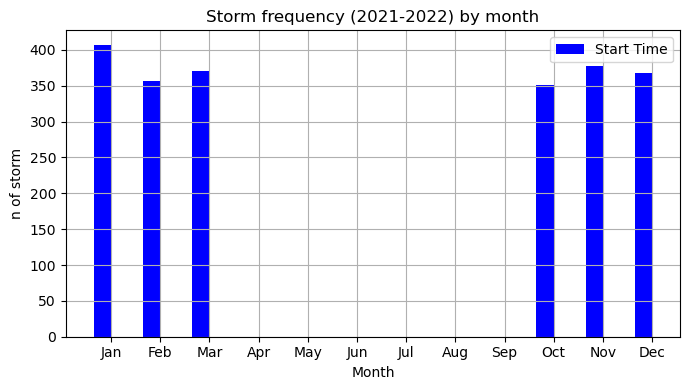

In [5]:
sta_month = trx_t['start_time'].dropna().unique()
sta_months = pd.Series([date.month for date in sta_month])
sta_counts = sta_months.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7., 4.))
months = range(1, 13)
bar_width = 0.35
sta_positions = [x - bar_width/2 for x in months]

ax.bar(sta_positions, sta_counts.reindex(months, fill_value=0), width=bar_width, label='Start Time', color='blue')

ax.set_title('Storm frequency (2021-2022) by month')
ax.set_xlabel('Month')
ax.set_ylabel('n of storm')
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plot_track(trx_t, 'vor', 'Extratropical Cyclone in Europe (2021-2022) from ERA5')

In [6]:
path = '/gws/nopw/j04/canari/users/bjharvey/tracks/'
output_file =  'merged_track.txt' 

with open(output_file, 'w') as outfile:
    for i in range(1980, 2022):
        syear = i
        eyear = i + 1
        filename = path + f'ERA5_VOR850_1hr_oct-mar{syear}{eyear}_DET.tr_trs_pos.1day-500km_addmslp_addwind925_addwind10m.new'
        with open(filename, 'r') as infile:
            outfile.write(infile.read())

In [6]:
var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

# Read the track data
trx_5 = read_tracks('merged_track.txt', var_names)
trx_5 = to_datetime(trx_5)
trx_5['season'] = trx_5['start_time'].apply(get_season)
#trx = add_wrap_id(trx)
trx_5

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season
0,1980-10-01 00:00:00,339.492126,33.568161,7.810895,339.1625,33.05409,1010.4920,345.6562,36.67446,19.87061,345.9375,36.39343,11.82803,10,1980-10-01 00:00:00,NaT,,1980-1981
1,1980-10-01 01:00:00,339.481232,33.770161,7.839233,338.9977,33.05897,1010.6600,346.2188,36.11240,20.48640,346.2188,35.83137,13.64472,10,1980-10-01 00:00:00,NaT,,1980-1981
2,1980-10-01 02:00:00,339.453674,33.978741,7.866363,339.0632,33.14759,1010.8860,345.6562,36.95549,22.16590,345.9375,36.67446,14.23902,10,1980-10-01 00:00:00,NaT,,1980-1981
3,1980-10-01 03:00:00,339.441986,34.200703,7.890915,339.0608,33.28640,1010.6940,345.3750,37.79858,22.74866,345.3750,37.23652,13.59618,10,1980-10-01 00:00:00,NaT,,1980-1981
4,1980-10-01 04:00:00,339.416016,34.423767,7.939483,338.9775,33.45113,1010.4100,344.8125,38.36064,20.36135,344.8125,37.23652,12.26464,10,1980-10-01 00:00:00,NaT,,1980-1981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9355752,2022-03-31 19:00:00,253.281281,52.871670,7.739974,253.5049,52.59162,997.0352,259.5938,53.53628,15.83161,251.1562,50.72598,11.71049,32623,2022-03-30 21:00:00,NaT,,2021-2022
9355753,2022-03-31 20:00:00,253.482239,52.941093,7.732875,253.7769,52.77341,997.3657,259.5938,53.53628,16.72056,251.4375,51.28803,11.48367,32623,2022-03-30 21:00:00,NaT,,2021-2022
9355754,2022-03-31 21:00:00,253.707535,53.047001,7.692232,254.0683,52.85543,997.1564,259.5938,53.53628,17.28619,251.7188,51.85009,11.25157,32623,2022-03-30 21:00:00,NaT,,2021-2022
9355755,2022-03-31 22:00:00,253.935608,53.155842,8.065690,254.2411,52.98973,996.6360,259.5938,53.53628,17.38802,253.1250,50.44494,12.57074,32623,2022-03-30 21:00:00,NaT,,2021-2022


In [11]:
plot_track(trx_5, 'vor', 'Extratropical Cyclone in Europe (1980-2022) from ERA5')

KeyboardInterrupt: 

Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x7f8606505630> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f8606505480> (for post_execute):


KeyboardInterrupt: 

In [10]:
trx_5['ID'].nunique()

30184

## ERA20C European Storm Track from CEDA

In [6]:
fpath = '/badc/deposited2018/robust-storm-track/data/era-20c/'
filename = fpath + 'ERA20C_tr_trs_VOR850_19802009_pos.addmslp_addspeed_addprecip_addomega_addlandwinds_addavgprecip.new_1000km2dayfiltered_RealProjregion2filtered_maxlandwindsinregion.txt'

with open(filename, 'r') as file:
    for i in range(8):
        print(file.readline().strip())

0
PER_INFO 1    180.00000
0 0
TRACK_NUM      1290 ADD_FLD    6  16 &111110
TRACK_ID  10 START_TIME 1980100100
POINT_NUM  85
1980100100 276.477875 32.726715 3.683265e+00 & 2.782872e+02 & 3.083150e+01 & 1.006408e+03 & 2.812500e+02 & 3.543850e+01 & 1.605729e+01 & 2.777344e+02 & 3.192976e+01 & 9.663895e-01 & 2.819531e+02 & 3.403502e+01 & -4.610014e-01 & 2.812500e+02 & 3.543850e+01 & 1.605729e+01 & 4.589758e-01 &
1980100103 276.621796 32.233791 3.502314e+00 & 2.769048e+02 & 3.058227e+01 & 1.005997e+03 & 2.819531e+02 & 3.614030e+01 & 1.649195e+01 & 2.756250e+02 & 2.982450e+01 & 1.212914e+00 & 2.819531e+02 & 3.403502e+01 & -3.588240e-01 & 2.819531e+02 & 3.614030e+01 & 1.649195e+01 & 4.290368e-01 &


In [10]:
var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca',
            'prec5deg', 'lon_cmorph_prec', 'lat_cmorph_prec', 'var_prec_max', 'var_prec_ave']

# Read the track data
trx_20c = read_tracks(filename, var_names)
trx_20c = to_datetime(trx_20c)
trx_20c['season'] = trx_20c['start_time'].apply(get_season)
#trx = add_wrap_id(trx)
trx_20c

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,...,var_ver,lon_wind_sca,lat_wind_sca,var_wind_sca,prec5deg,ID,start_time,median_time,name,season
0,1980-10-01 00:00:00,276.477875,32.726715,3.683265,278.28720,30.83150,1006.408,281.2500,35.4385,16.05729,...,-0.461001,281.2500,35.4385,16.05729,0.458976,10,1980-10-01 00:00:00,NaT,,1980-1981
1,1980-10-01 03:00:00,276.621796,32.233791,3.502314,276.90480,30.58227,1005.997,281.9531,36.1403,16.49195,...,-0.358824,281.9531,36.1403,16.49195,0.429037,10,1980-10-01 00:00:00,NaT,,1980-1981
2,1980-10-01 06:00:00,276.667175,31.761646,3.099555,NaN,NaN,1007.540,281.2500,35.4385,17.06239,...,-0.238685,281.2500,35.4385,17.06239,0.430904,10,1980-10-01 00:00:00,NaT,,1980-1981
3,1980-10-01 09:00:00,276.765594,31.485422,3.484782,NaN,NaN,1007.055,280.5469,34.7368,15.26498,...,-0.416270,280.5469,34.7368,15.26498,0.317605,10,1980-10-01 00:00:00,NaT,,1980-1981
4,1980-10-01 12:00:00,277.338654,31.542223,3.316391,NaN,NaN,1008.109,284.0625,30.5263,13.23500,...,-0.350605,279.8438,34.7368,13.20241,0.325036,10,1980-10-01 00:00:00,NaT,,1980-1981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48539,2010-03-31 09:00:00,75.058159,63.905251,3.939470,76.44798,63.91080,1011.411,82.9688,62.8068,13.24518,...,-0.230447,82.9688,62.8068,13.24518,0.134497,7060,2010-03-25 21:00:00,NaT,,2009-2010
48540,2010-03-31 12:00:00,77.052773,63.329147,3.912337,76.74723,64.04748,1009.522,76.6406,57.8946,14.09756,...,-0.284631,76.6406,57.8946,14.09756,0.145633,7060,2010-03-25 21:00:00,NaT,,2009-2010
48541,2010-03-31 15:00:00,78.209328,63.829582,4.370348,78.89957,63.53005,1011.414,86.4844,63.5086,15.12425,...,-0.250300,86.4844,63.5086,15.12425,0.135716,7060,2010-03-25 21:00:00,NaT,,2009-2010
48542,2010-03-31 18:00:00,79.054199,64.184853,4.157902,78.83983,63.92422,1008.993,87.1875,64.2103,13.95099,...,-0.210946,87.1875,64.2103,13.95099,0.106958,7060,2010-03-25 21:00:00,NaT,,2009-2010


In [11]:
trx_20c['ID'].nunique()

1181

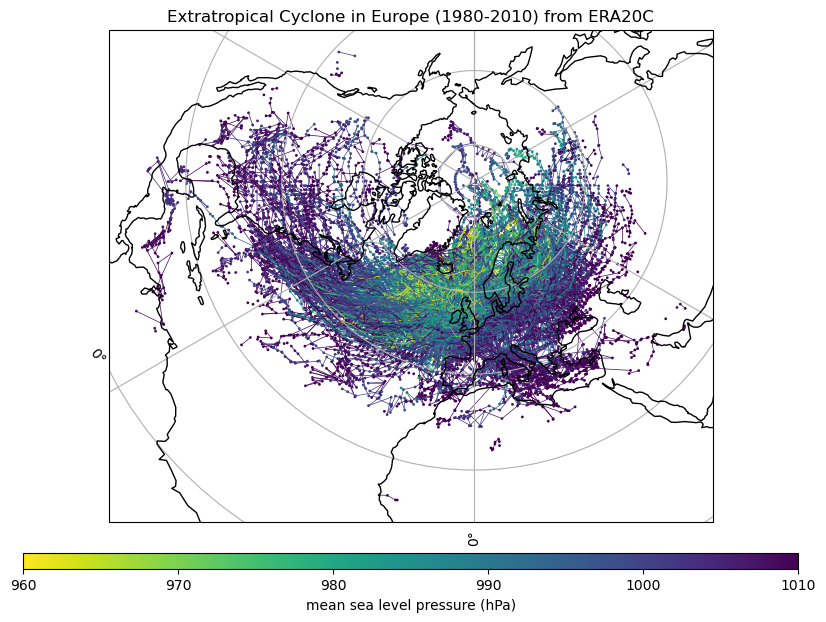

In [29]:
plot_track(trx_20c, 'mslp', 'Extratropical Cyclone in Europe (1980-2010) from ERA20C')

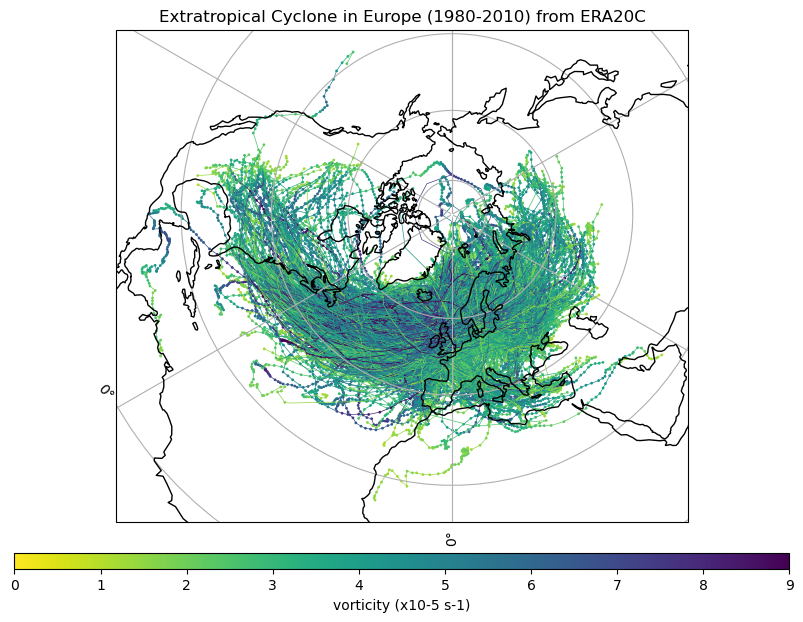

In [30]:
plot_track(trx_20c, 'vor', 'Extratropical Cyclone in Europe (1980-2010) from ERA20C')

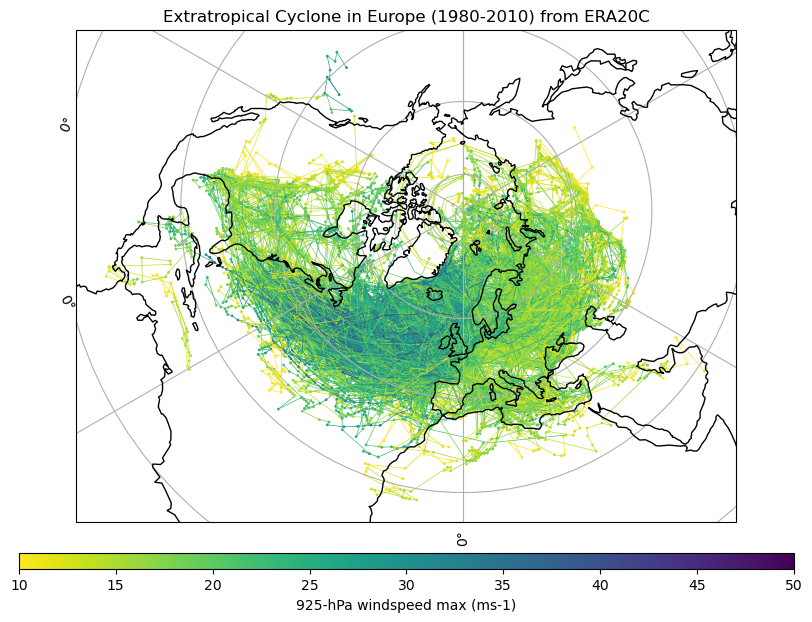

In [34]:
plot_track(trx_20c, 'wind', 'Extratropical Cyclone in Europe (1980-2010) from ERA20C')

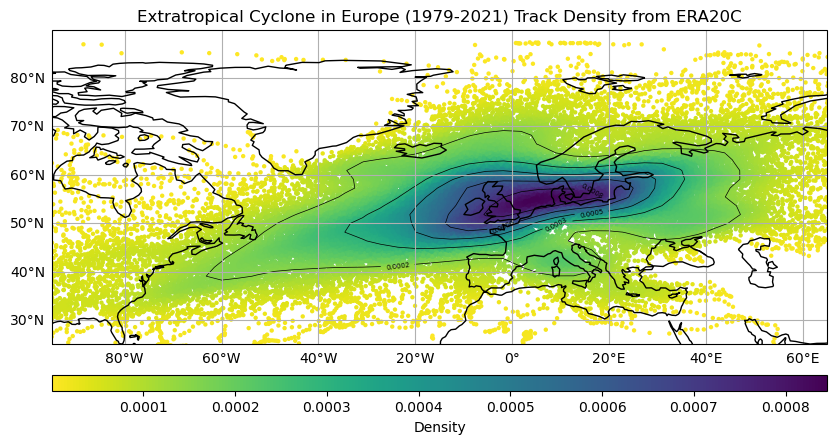

In [33]:
plot_density(trx_20c, 'vor', 'Extratropical Cyclone in Europe (1979-2021) Track Density from ERA20C')

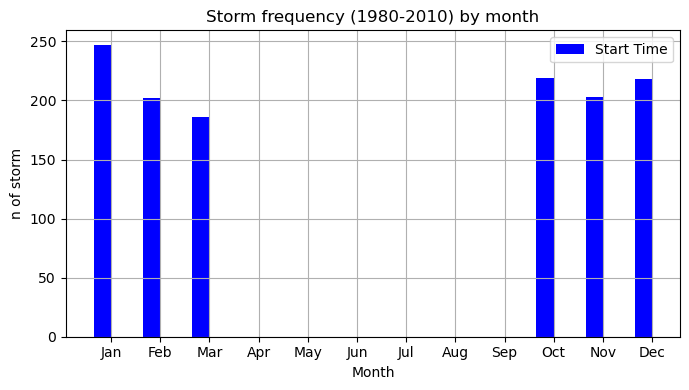

In [46]:
sta_month = trx_20c['start_time'].dropna().unique()
sta_months = pd.Series([date.month for date in sta_month])
sta_counts = sta_months.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7., 4.))
months = range(1, 13)
bar_width = 0.35
sta_positions = [x - bar_width/2 for x in months]

ax.bar(sta_positions, sta_counts.reindex(months, fill_value=0), width=bar_width, label='Start Time', color='blue')

ax.set_title('Storm frequency (1980-2010) by month')
ax.set_xlabel('Month')
ax.set_ylabel('n of storm')
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()

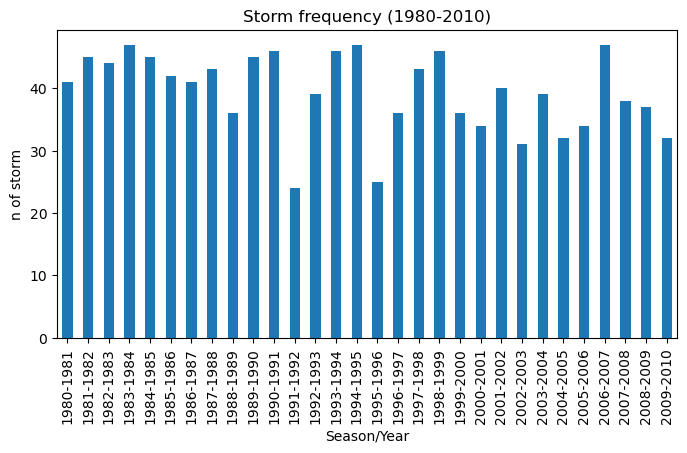

In [44]:
trx_drop = trx_20c.drop_duplicates(subset=['ID'])
season_counts = trx_drop['season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8., 4.))
season_counts.plot(kind='bar', color='tab:blue')
plt.title('Storm frequency (1980-2010)')
plt.xlabel('Season/Year')
plt.ylabel('n of storm')
plt.xticks(rotation=90)

#plt.grid(True)
plt.show()

#print("\nCounts per Season:")
#print(season_counts)

## C3S Storm Track ERA5 from CDS

In [6]:
file_track = 'C3S_StormTracks_era5_19792021_0100_v1.dat'

var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec',
            'lon_ver', 'lat_ver', 'var_ver', 'lon_wind_sca', 'lat_wind_sca', 'var_wind_sca']

# Read the track data
trx_2021 = read_tracks(file_track, var_names)
trx_2021 = to_datetime(trx_2021)
trx_2021['season'] = trx_2021['median_time'].apply(get_season)
trx_2021

,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,...,start_time,median_time,name,lon_ver,lat_ver,var_ver,lon_wind_sca,lat_wind_sca,var_wind_sca,season
0,1979-12-03 00:00:00,306.875519,41.814056,3.916188,308.41530,41.69593,1000.7820,308.5312,41.4520,27.91070,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
1,1979-12-03 03:00:00,310.245422,42.722225,4.112222,310.51570,43.04460,999.0791,311.3438,42.0140,29.84519,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
2,1979-12-03 06:00:00,313.649384,43.700222,4.251033,315.09280,43.77155,994.7399,315.5625,43.4192,29.57939,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
3,1979-12-03 09:00:00,317.070068,44.814579,4.889229,317.38890,46.55165,989.8234,318.6562,44.2623,31.45879,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
4,1979-12-03 12:00:00,320.233734,46.265247,5.254075,320.37530,47.23037,989.8195,325.1250,46.5105,37.14414,...,1979-12-03 00:00:00,1979-12-05 06:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,1979-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6054,2021-03-24 15:00:00,10.082969,69.874252,5.593984,11.17829,69.98547,963.1310,14.3438,67.5878,38.14269,...,2021-03-21 18:00:00,2021-03-23 09:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021
6055,2021-03-24 18:00:00,14.000390,70.250389,4.755875,15.12591,70.45399,965.2739,14.0625,67.5878,36.43958,...,2021-03-21 18:00:00,2021-03-23 09:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021
6056,2021-03-24 21:00:00,19.299009,70.682640,4.126274,18.34388,70.83690,967.6423,15.7500,68.1498,28.82528,...,2021-03-21 18:00:00,2021-03-23 09:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021
6057,2021-03-25 00:00:00,24.670216,70.705574,4.089319,20.13250,70.71175,971.4703,16.3125,69.2740,26.18828,...,2021-03-21 18:00:00,2021-03-23 09:00:00,C3S_STORM_TRACKS_ERA5,NaN,NaN,NaN,NaN,NaN,NaN,2020-2021


In [7]:
trx_2021.to_excel("ERA5_ET_track_1979-2021.xlsx")

In [48]:
trx_2021['ID'].nunique()

120

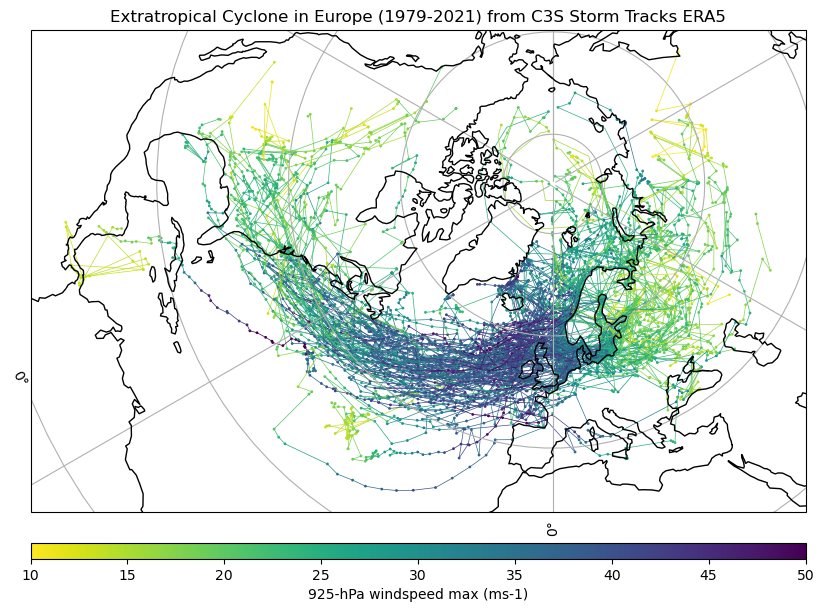

In [36]:
plot_track(trx_2021, 'wind', 'Extratropical Cyclone in Europe (1979-2021) from C3S Storm Tracks ERA5')

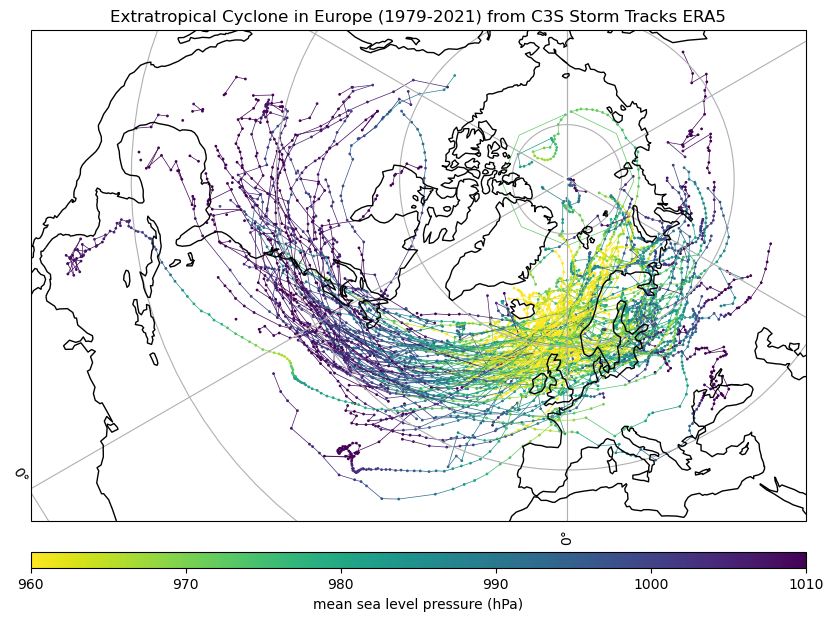

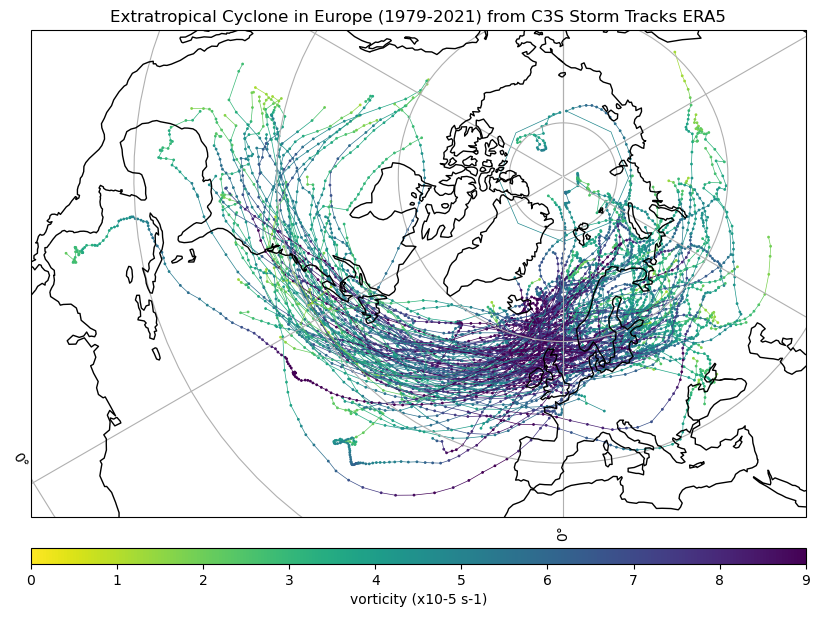

In [37]:
plot_track(trx_2021, 'mslp', 'Extratropical Cyclone in Europe (1979-2021) from C3S Storm Tracks ERA5')
plot_track(trx_2021, 'vor', 'Extratropical Cyclone in Europe (1979-2021) from C3S Storm Tracks ERA5')

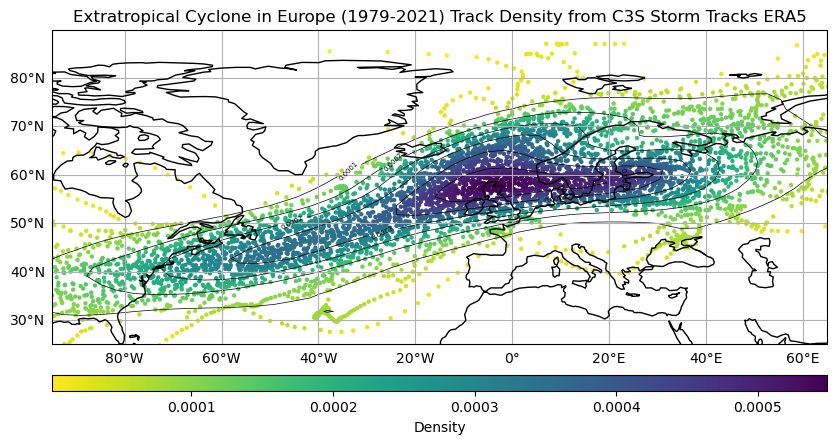

In [38]:
plot_density(trx_2021, 'vor', 'Extratropical Cyclone in Europe (1979-2021) Track Density from C3S Storm Tracks ERA5')

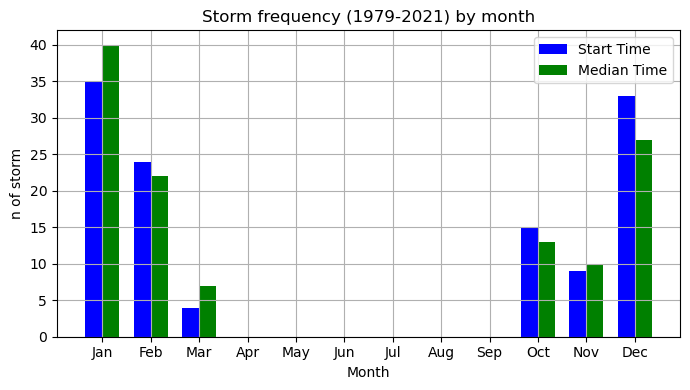

In [47]:
sta_month = trx_2021['start_time'].dropna().unique()
med_month = trx_2021['median_time'].dropna().unique()

sta_months = pd.Series([date.month for date in sta_month])
med_months = pd.Series([date.month for date in med_month])

sta_counts = sta_months.value_counts().sort_index()
med_counts = med_months.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7., 4.))
months = range(1, 13)
bar_width = 0.35

sta_positions = [x - bar_width/2 for x in months]
med_positions = [x + bar_width/2 for x in months]

ax.bar(sta_positions, sta_counts.reindex(months, fill_value=0), width=bar_width, label='Start Time', color='blue')
ax.bar(med_positions, med_counts.reindex(months, fill_value=0), width=bar_width, label='Median Time', color='green')

ax.set_title('Storm frequency (1979-2021) by month')
ax.set_xlabel('Month')
ax.set_ylabel('n of storm')
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()

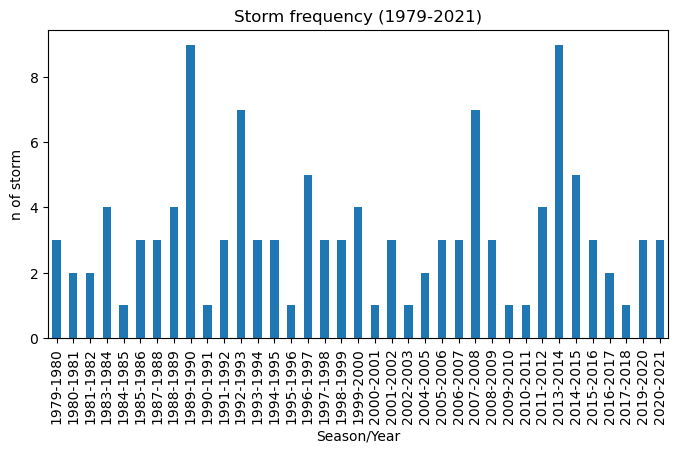

In [43]:
trx_drop = trx_2021.drop_duplicates(subset=['ID'])
season_counts = trx_drop['season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8., 4.))
season_counts.plot(kind='bar', color='tab:blue')
plt.title('Storm frequency (1979-2021)')
plt.xlabel('Season/Year')
plt.ylabel('n of storm')
plt.xticks(rotation=90)

#plt.grid(True)
plt.show()

#print("\nCounts per Season:")
#print(season_counts)

## Storm XAver 2013 Footprint

In [2]:
ncdat = xr.open_dataset('C3S_fp_era5_sd_20131205_97_0_Xaver_v1.nc')
ncdat

<xarray.Dataset>
Dimensions:    (Longitude: 3944, Latitude: 2432, z: 1)
Coordinates:
  * Longitude  (Longitude) float64 -25.36 -25.34 -25.32 ... 40.32 40.34 40.36
  * Latitude   (Latitude) float64 70.35 70.33 70.32 70.3 ... 29.87 29.85 29.83
  * z          (z) int32 1
Data variables:
    FX         (z, Latitude, Longitude) float32 ...
Attributes:
    crs:              +proj=longlat +datum=WGS84
    crs_format:       PROJ.4
    Conventions:      CF-1.4
    created_by:       R, packages ncdf4 and raster (version 2.6-7)
    date:             2019-07-02 12:55:37
    title:            C3S operational wind storm
    institution:      Royal Netherlands Meteorological Institute (KNMI)
    contact:          Please contact Copernicus User Support on the Copernicu...
    licence:          Licence to use Copernicus products
    version:          v1
    product_version:  1

In [4]:
fx = ncdat['FX'].sel(z=1).values
lats = ncdat['Latitude']
lons = ncdat['Longitude']

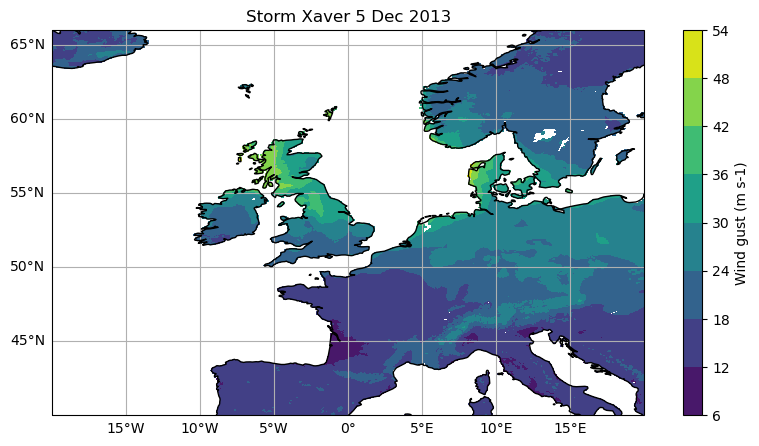

In [7]:
fig, ax = plt.subplots(figsize=(10., 5.),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})
ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
ax.set_extent([-20, 20, 40, 66], crs=ccrs.PlateCarree())


wg = ax.contourf(lons, lats, fx, cmap='viridis', transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

ax.set_title('Storm Xaver 5 Dec 2013')
labelo = 'Wind gust (m s-1)'
cbar = plt.colorbar(wg, ax=ax, orientation='vertical')
cbar.set_label(labelo)

plt.show()

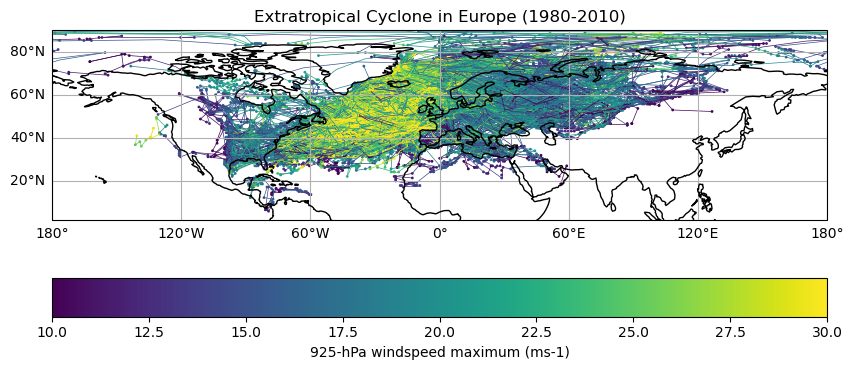

In [10]:
#trx['lon_vor'] = trx['lon_vor'].apply(lambda lon: ((lon + 180) % 360) - 180)
trx['lon_wind'] = trx['lon_wind'].apply(lambda lon: ((lon + 180) % 360) - 180)

fig, ax = plt.subplots(figsize=(10., 5.),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})
ax.add_feature(cartopy.feature.COASTLINE, zorder=17)

cmap = plt.cm.viridis
norm = plt.Normalize(10, 30)

for name, group in trx.groupby('TRACK_ID'):
    #points = group[['lon_vor', 'lat_vor']].values
    points = group[['lon_wind', 'lat_wind']].values
    lc = ccrs.Geodetic()
    #ax.scatter(group['lon_vor'], group['lat_vor'], color=cmap(norm(group['var_vor'])), s=1, transform=lc)
    ax.scatter(group['lon_wind'], group['lat_wind'], color=cmap(norm(group['var_wind'])), s=1, transform=lc)
    for i in range(len(points)-1):
        line = np.array([points[i], points[i+1]])
        #ax.plot(line[:, 0], line[:, 1], color=cmap(norm((group['var_vor'].iloc[i] + group['var_vor'].iloc[i+1])/2)),
        #        linewidth=0.5, transform=lc)  
        ax.plot(line[:, 0], line[:, 1], color=cmap(norm((group['var_wind'].iloc[i] + group['var_wind'].iloc[i+1])/2)),
                linewidth=0.5, transform=lc)  

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

ax.set_title('Extratropical Cyclone in Europe (1980-2010)')
labelinrv = 'Relative Vorticity (x10-5 s-1)'
labelinws = '925-hPa windspeed maximum (ms-1)'
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='horizontal', label=labelinws)

plt.show()

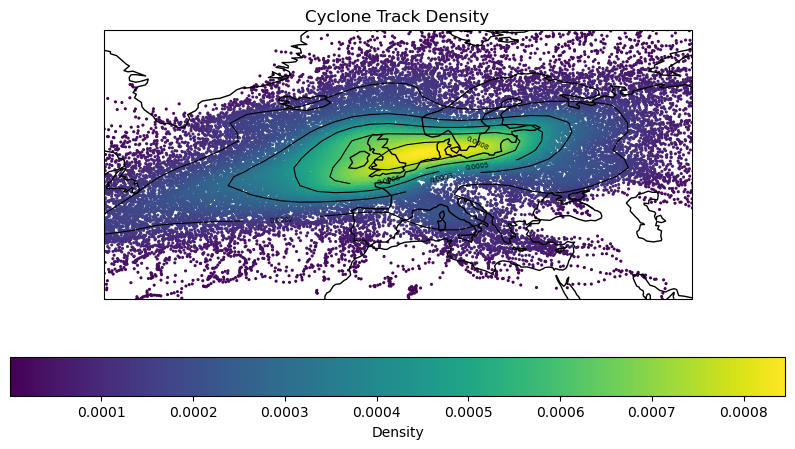

In [19]:
from scipy.stats import gaussian_kde

trx['lon_vor'] = trx['lon_vor'].apply(lambda lon: ((lon + 180) % 360) - 180)
trx['lat_vor'] = trx['lat_vor'].apply(lambda lat: np.clip(lat, -90, 90))

fig, ax = plt.subplots(figsize=(10., 5.),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cartopy.feature.COASTLINE, zorder=17)

lon = np.linspace(-180, 180, 100)
lat = np.linspace(-90, 90, 100)
lon_grid, lat_grid = np.meshgrid(lon, lat)
grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

xy = np.vstack([trx['lon_vor'], trx['lat_vor']])
kde = gaussian_kde(xy)
z = kde(grid_coords).reshape(lon_grid.shape)

sc = ax.scatter(trx['lon_vor'], trx['lat_vor'], c=kde(xy), s=5, cmap=plt.cm.viridis, edgecolor='none', transform=ccrs.PlateCarree())
cs = ax.contour(lon_grid, lat_grid, z, levels=6, colors='k', linewidths=0.8, transform=ccrs.PlateCarree())
plt.clabel(cs, inline=1, fontsize=5, fmt='%.4f')

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal')
cbar.set_label('Density')

ax.set_extent([-60, 60, 25, 80], crs=ccrs.PlateCarree())
ax.set_title('Cyclone Track Density')
plt.show()

In [11]:
f = open(file,'r')
print(f)
rd = f.readline()
print(rd)
rd = f.readline()
rd = f.readline().split()
print(rd)
TRACK_NUM = int(rd[1])

for n in range(TRACK_NUM):
    rd = f.readline().split()
    print(rd)
    TRACK_ID = int(rd[1])
    print(TRACK_ID)
    rd = f.readline().split()
    POINT_NUM = int(rd[1])
    TRACK_TIME=[]; TRACK_DATE=[];TRACK_LON=[]; TRACK_LAT=[]; TRACK_VOR=[];TRACK_WND10=[];TRACK_MSLP=[];TRACK_MONTH=[];TRACK_YEAR=[]
    TRACK_WIND=[]; radius_10m=[]; radius_925=[]
    for i in range(POINT_NUM):
       rd = f.readline().split()
       TRACK_TIME.append(int(rd[0].lstrip('0')))
       TRACK_DATE.append(int(rd[0][4:8].lstrip('0')))
       TRACK_MONTH.append(int(rd[0][4:6].lstrip('0')))
       TRACK_YEAR.append(int(rd[0][:4].lstrip('0')))
       TRACK_LON.append(float(rd[1].lstrip('0')))
       TRACK_LAT.append(float(rd[2].lstrip('0')))
       TRACK_VOR.append(float(rd[3].lstrip('0')))
       TRACK_WIND.append(float(rd[-6].lstrip('0')))
       radius_10m.append(float(rd[-2].lstrip('0')))
       radius_925.append(float(rd[-4].lstrip('0')))

<_io.TextIOWrapper name='/badc/deposited2018/robust-storm-track/data/era-20c/ERA20C_tr_trs_VOR850_19802009_pos.addmslp_addspeed_addprecip_addomega_addlandwinds_addavgprecip.new_1000km2dayfiltered_RealProjregion2filtered_maxlandwindsinregion.txt' mode='r' encoding='UTF-8'>
0

['0', '0']


In [35]:
trx.to_excel("ERA20C_ET_track_1980-2010.xlsx")  